# Binary Skin Lesion Classification: Curated vs. Uncurated Datasets

This notebook trains and evaluates convolutional neural networks for binary classification of skin lesion images as benign or malignant.

Two models are compared:

- A model trained on the original uncurated dataset
- A model trained on a curated version of the dataset

The workflow includes model training, test-set evaluation, confusion matrices, and classification metrics. GradCAM visualisation was also used to highlight the regions which influenced the model's predictions. This was developed by another team member and is provided separately in the notebook named "gradcam-visualisation.ipynb".

## Requirements

- Google Colab (GPU acceleration recommended)
- TensorFlow/Keras
- Curated and uncurated datasets stored in Google Drive

In [6]:
# IMPORTS

from pathlib import Path
import json

import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from google.colab import drive
from sklearn.metrics import confusion_matrix
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Mount Google Drive
drive.mount("/content/drive")

# Change only this path to match your Google Drive folder
PROJECT_DIR = Path("/content/drive/MyDrive")

UNCURATED_DIR = PROJECT_DIR / "dataset_uncurated"
CURATED_DIR = PROJECT_DIR / "dataset_curated"
OUTPUT_DIR = PROJECT_DIR / "outputs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# CONFIGURATIONS

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 25
THRESHOLD = 0.5
SEED = 42

MODEL_TAG = f"{EPOCHS}epochs"

UNCURATED_MODEL_PATH = OUTPUT_DIR / f"cnn_uncurated_{MODEL_TAG}.keras"
CURATED_MODEL_PATH = OUTPUT_DIR / f"cnn_curated_{MODEL_TAG}.keras"

UNCURATED_HISTORY_PATH = OUTPUT_DIR / f"history_uncurated_{MODEL_TAG}.json"
CURATED_HISTORY_PATH = OUTPUT_DIR / f"history_curated_{MODEL_TAG}.json"

tf.keras.utils.set_random_seed(SEED)

Mounted at /content/drive


In [ ]:
# DATA GENERATORS

train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=30,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2]
)
val_datagen = ImageDataGenerator(rescale=1./255)

def make_generators(base_dir):
    train_gen = train_datagen.flow_from_directory(
        str(base_dir / "Training"),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=True,
        seed=SEED,
    )

    val_gen = val_datagen.flow_from_directory(
        str(base_dir / "Validation"),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=False,
    )

    return train_gen, val_gen

In [ ]:
# CNN ARCHITECTURE

def build_model():
    model = models.Sequential([
        layers.Input(shape=IMG_SIZE + (3,)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
# CALLBACKS

def make_callbacks():
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=50,
        restore_best_weights=True,
        verbose=1,
    )

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    )

    return [early_stop, reduce_lr]

In [7]:
# PLOT FUNCTION

def plot_history(history, label, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
    f"CNN Training — {label} ({EPOCHS} Epochs)",
    fontsize=13,
    fontweight="bold",
)
    axes[0].plot(history.history['accuracy'],     'r--', label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], 'r-',  label='Val Accuracy')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'],     'b--', label='Train Loss')
    axes[1].plot(history.history['val_loss'], 'b-',  label='Val Loss')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

# COMBINED PLOT

def plot_combined(hist_unc, hist_cur):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(
    f"{EPOCHS}-Epoch Comparison — Curated vs Uncurated",
    fontsize=13,
    fontweight="bold",
)

    # Accuracy
    axes[0].plot(hist_unc.history['accuracy'],     'r--', label='Uncurated - Train')
    axes[0].plot(hist_unc.history['val_accuracy'], 'r-',  label='Uncurated - Val')
    axes[0].plot(hist_cur.history['accuracy'],     'b--', label='Curated - Train')
    axes[0].plot(hist_cur.history['val_accuracy'], 'b-',  label='Curated - Val')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(hist_unc.history['loss'],     'r--', label='Uncurated - Train')
    axes[1].plot(hist_unc.history['val_loss'], 'r-',  label='Uncurated - Val')
    axes[1].plot(hist_cur.history['loss'],     'b--', label='Curated - Train')
    axes[1].plot(hist_cur.history['val_loss'], 'b-',  label='Curated - Val')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(
    OUTPUT_DIR / f"training_curves_combined_{MODEL_TAG}.png",
    dpi=300,
    bbox_inches="tight",
)
    plt.show()


════ Training Uncurated Model ════
Found 2965 images belonging to 2 classes.
Found 1038 images belonging to 2 classes.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,585,153 (17.49 MB)

 Trainable params: 4,584,193 (17.49 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 807s 9s/step - accuracy: 0.6857 - loss: 0.7403 - val_accuracy: 0.3536 - val_loss: 2.1817 - learning_rate: 1.0000e-04
Epoch 2/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 297s 3s/step - accuracy: 0.7369 - loss: 0.5330 - val_accuracy: 0.3536 - val_loss: 3.6862 - learning_rate: 1.0000e-04
Epoch 3/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 283s 3s/step - accuracy: 0.7541 - loss: 0.5063 - val_accuracy: 0.3536 - val_loss: 3.2564 - learning_rate: 1.0000e-04
Epoch 4/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 295s 3s/step - accuracy: 0.7703 - loss: 0.4795 - val_accuracy: 0.3709 - val_loss: 1.9721 - learning_rate: 1.0000e-04
Epoch 5/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 300s 3s/step - accuracy: 0.7609 - loss: 0.4720 - val_accuracy: 0.5539 - val_loss: 1.0017 - learning_rate: 1.0000e-04
Epoch 6/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 297s 3s/step - accuracy: 0.7757 - loss: 0.4674 - val_accuracy: 0.7900 - val_loss: 0.4459 - learning_rate: 1.0000e-04
Epoch 7/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 286s 3s/step - accuracy: 0.7771 

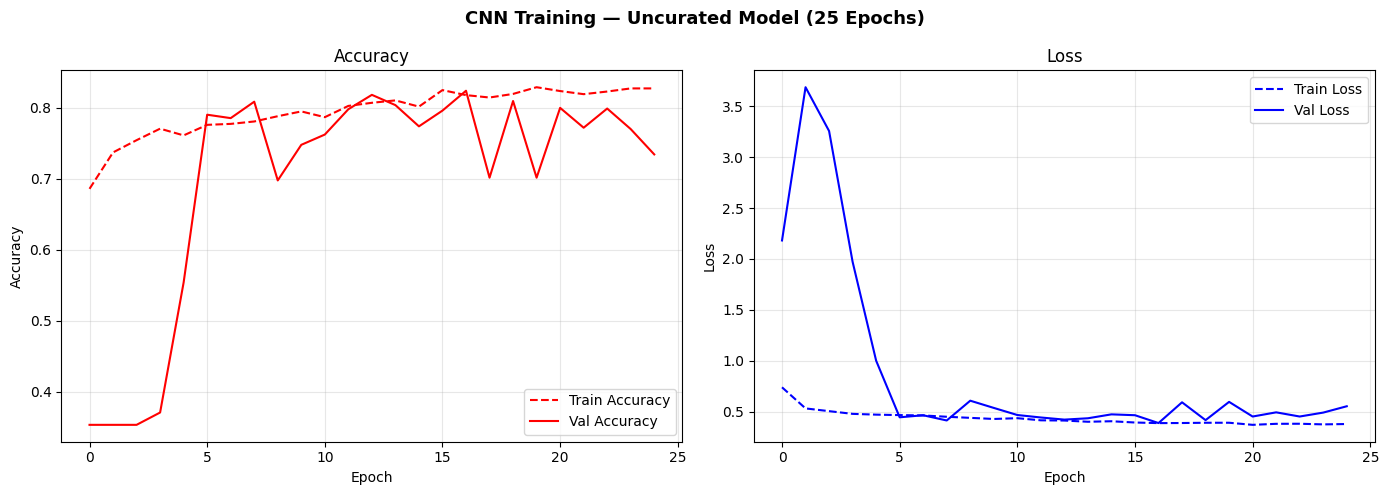


Uncurated — Best val accuracy: 82.37%
Uncurated — Epochs run: 25 / 25


In [ ]:
# TRAIN UNCURATED

print('\n════ Training Uncurated Model ════')
unc_train, unc_val = make_generators(UNCURATED_DIR)
model_uncurated = build_model()
model_uncurated.summary()

history_uncurated = model_uncurated.fit(
    unc_train,
    validation_data=unc_val,
    epochs=EPOCHS,
    callbacks=make_callbacks()
)

model_uncurated.save(UNCURATED_MODEL_PATH)

with open(UNCURATED_HISTORY_PATH, "w") as file:
    json.dump(history_uncurated.history, file)

plot_history(
    history_uncurated,
    "Uncurated Model",
    OUTPUT_DIR / f"training_curves_uncurated_{MODEL_TAG}.png",
)

print(f'\nUncurated — Best val accuracy: {max(history_uncurated.history["val_accuracy"])*100:.2f}%')
print(f'Uncurated — Epochs run: {len(history_uncurated.history["accuracy"])} / {EPOCHS}')


════ Training Curated Model ════
Found 2955 images belonging to 2 classes.
Found 976 images belonging to 2 classes.
Epoch 1/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 898s 10s/step - accuracy: 0.6596 - loss: 0.8191 - val_accuracy: 0.6240 - val_loss: 1.4352 - learning_rate: 1.0000e-04
Epoch 2/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 330s 4s/step - accuracy: 0.6988 - loss: 0.5804 - val_accuracy: 0.6240 - val_loss: 2.0557 - learning_rate: 1.0000e-04
Epoch 3/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 317s 3s/step - accuracy: 0.7032 - loss: 0.5677 - val_accuracy: 0.6240 - val_loss: 1.7943 - learning_rate: 1.0000e-04
Epoch 4/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 327s 4s/step - accuracy: 0.7151 - loss: 0.5574 - val_accuracy: 0.6516 - val_loss: 1.1795 - learning_rate: 1.0000e-04
Epoch 5/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 317s 3s/step - accuracy: 0.7093 - loss: 0.5512 - val_accuracy: 0.7295 - val_loss: 0.5366 - learning_rate: 1.0000e-04
Epoch 6/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 324s 3s/step - accuracy: 0.7364 - loss: 0.5329 - val_accuracy: 0.7480

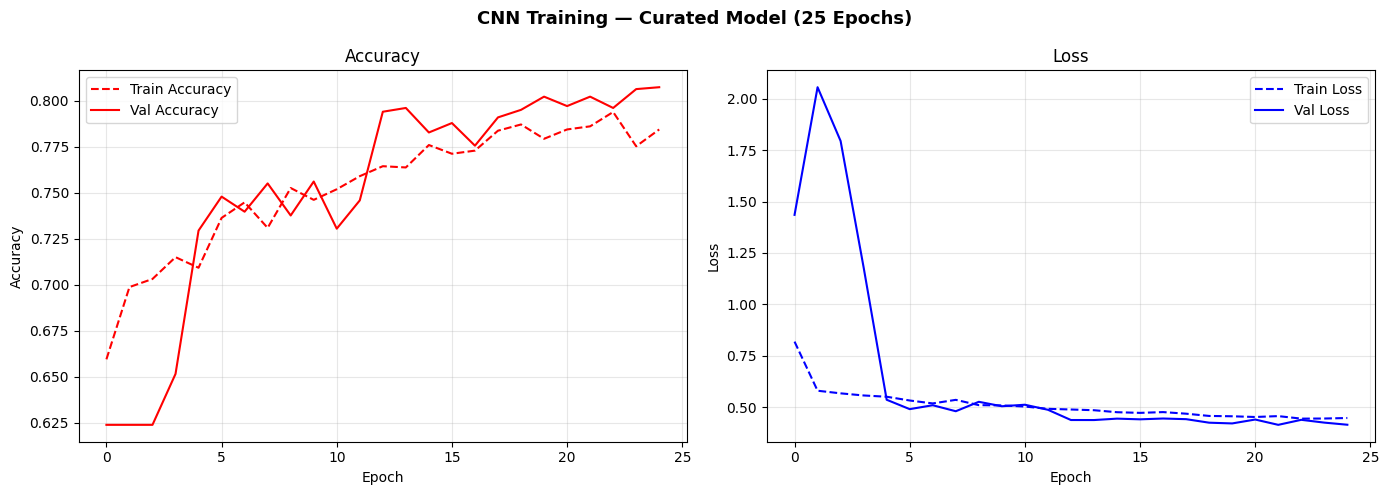


Curated — Best val accuracy: 80.74%
Curated — Epochs run: 25 / 25


In [ ]:
# TRAIN CURATED

print('\n════ Training Curated Model ════')
cur_train, cur_val = make_generators(CURATED_DIR)
model_curated = build_model()

history_curated = model_curated.fit(
    cur_train,
    validation_data=cur_val,
    epochs=EPOCHS,
    callbacks=make_callbacks()
)

model_curated.save(CURATED_MODEL_PATH)

with open(CURATED_HISTORY_PATH, "w") as file:
    json.dump(history_curated.history, file)

plot_history(
    history_curated,
    "Curated Model",
    OUTPUT_DIR / f"training_curves_curated_{MODEL_TAG}.png",
)

print(f'\nCurated — Best val accuracy: {max(history_curated.history["val_accuracy"])*100:.2f}%')
print(f'Curated — Epochs run: {len(history_curated.history["accuracy"])} / {EPOCHS}')


════ Generating Combined Plot ════


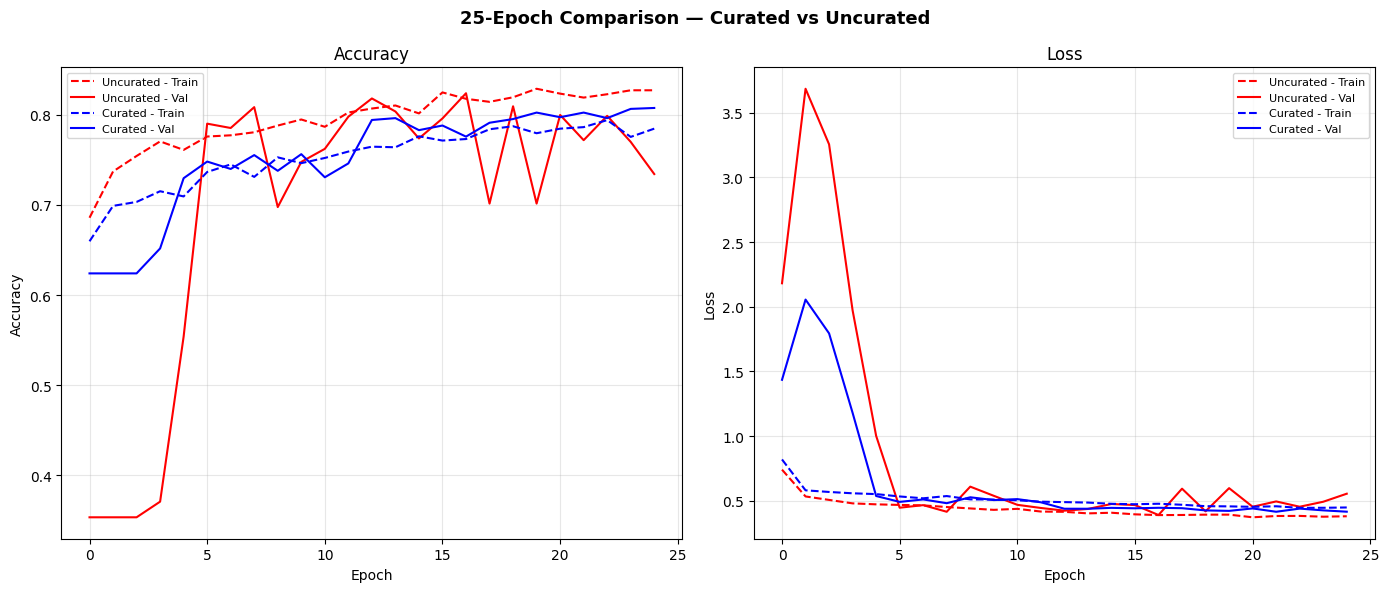


════ TRAINING COMPLETE ════
Uncurated — Best val accuracy: 82.37%
Curated   — Best val accuracy: 80.74%

Files saved:
  cnn_uncurated_25epochs.keras
  cnn_curated_25epochs.keras
  history_uncurated_25epochs.json
  history_curated_25epochs.json
  training_curves_uncurated_25epochs.png
  training_curves_curated_25epochs.png
  training_curves_combined_25epochs.png


In [9]:
# COMBINED COMPARISON PLOT

print('\n════ Generating Combined Plot ════')
plot_combined(history_uncurated, history_curated)

# SUMMARY

print('\n════ TRAINING COMPLETE ════')
print(f'Uncurated — Best val accuracy: {max(history_uncurated.history["val_accuracy"])*100:.2f}%')
print(f'Curated   — Best val accuracy: {max(history_curated.history["val_accuracy"])*100:.2f}%')
saved_files = [
    UNCURATED_MODEL_PATH,
    CURATED_MODEL_PATH,
    UNCURATED_HISTORY_PATH,
    CURATED_HISTORY_PATH,
    OUTPUT_DIR / f"training_curves_uncurated_{MODEL_TAG}.png",
    OUTPUT_DIR / f"training_curves_curated_{MODEL_TAG}.png",
    OUTPUT_DIR / f"training_curves_combined_{MODEL_TAG}.png",
]

print("\nFiles saved:")
for path in saved_files:
    print(f"  {path.name}")

In [ ]:
# TESTING

# CONFIGURATIONS

CURATED_TEST_DIR = CURATED_DIR / "Test"
UNCURATED_TEST_DIR = UNCURATED_DIR / "Test"

# DATA GENERATORS

def make_test_generator(data_dir):
    datagen = ImageDataGenerator(rescale=1./255)
    return datagen.flow_from_directory(
        data_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )

curated_test   = make_test_generator(CURATED_TEST_DIR)
uncurated_test = make_test_generator(UNCURATED_TEST_DIR)

print(f'Curated   — {len(curated_test.classes)} samples | {curated_test.class_indices}')
print(f'Uncurated — {len(uncurated_test.classes)} samples | {uncurated_test.class_indices}')

# LOAD MODELS

curated_model   = load_model(CURATED_MODEL_PATH)
uncurated_model = load_model(UNCURATED_MODEL_PATH)

# PREDICTIONS

print('\nRunning predictions...')
curated_probs   = curated_model.predict(curated_test,   verbose=1).ravel()
uncurated_probs = uncurated_model.predict(uncurated_test, verbose=1).ravel()

curated_preds = (curated_probs >= THRESHOLD).astype(int)
uncurated_preds = (uncurated_probs >= THRESHOLD).astype(int)

curated_labels   = curated_test.classes
uncurated_labels = uncurated_test.classes

Found 533 images belonging to 2 classes.
Found 533 images belonging to 2 classes.
Curated   — 533 samples | {'Benign': 0, 'Malignant': 1}
Uncurated — 533 samples | {'Benign': 0, 'Malignant': 1}

Running predictions...
17/17 ━━━━━━━━━━━━━━━━━━━━ 106s 6s/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 119s 7s/step



Curated   — Sensitivity: 0.397 | Specificity: 0.741 | F1: 0.517 | Accuracy: 0.516
Uncurated — Sensitivity: 0.879 | Specificity: 0.654 | F1: 0.852 | Accuracy: 0.801


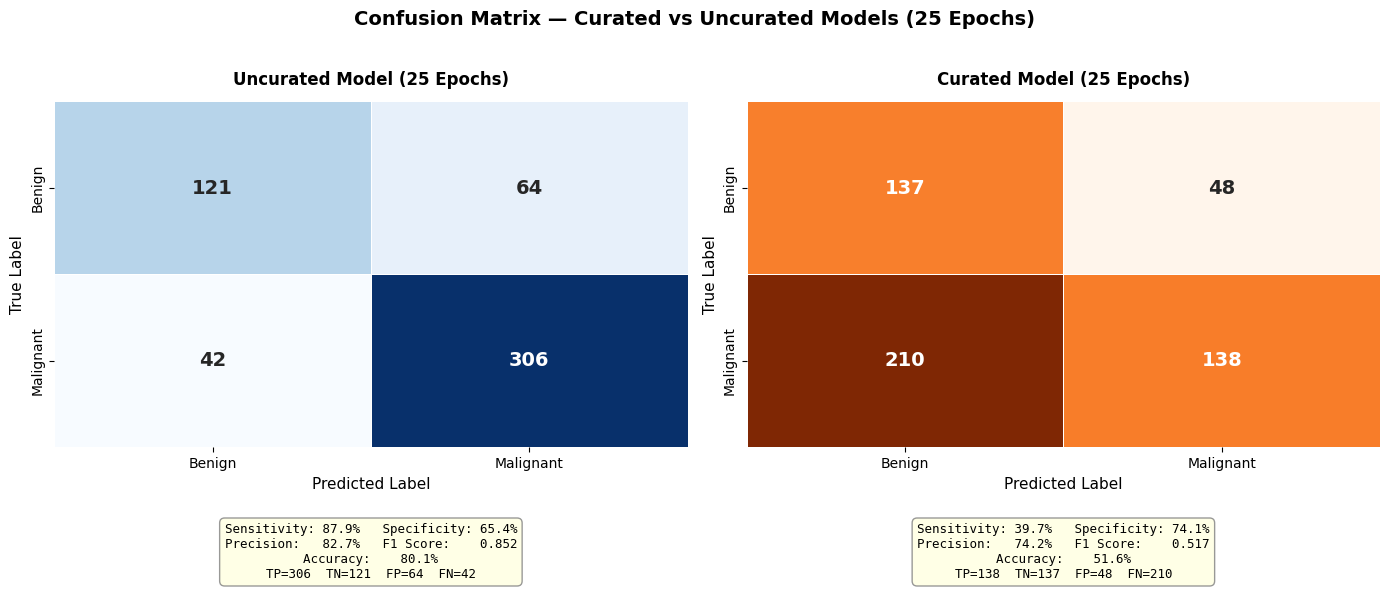

In [ ]:
# CONFUSION MATRICES

cm_c = confusion_matrix(curated_labels,   curated_preds)
cm_u = confusion_matrix(uncurated_labels, uncurated_preds)

# METRICS

def get_metrics(cm):
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1          = 2 * precision * sensitivity / (precision + sensitivity) \
                  if (precision + sensitivity) > 0 else 0
    accuracy    = (tp + tn) / (tp + tn + fp + fn)
    return tn, fp, fn, tp, sensitivity, specificity, precision, f1, accuracy

tn_c, fp_c, fn_c, tp_c, sens_c, spec_c, prec_c, f1_c, acc_c = get_metrics(cm_c)
tn_u, fp_u, fn_u, tp_u, sens_u, spec_u, prec_u, f1_u, acc_u = get_metrics(cm_u)

print(f'\nCurated   — Sensitivity: {sens_c:.3f} | Specificity: {spec_c:.3f} | '
      f'F1: {f1_c:.3f} | Accuracy: {acc_c:.3f}')
print(f'Uncurated — Sensitivity: {sens_u:.3f} | Specificity: {spec_u:.3f} | '
      f'F1: {f1_u:.3f} | Accuracy: {acc_u:.3f}')

# PLOT

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"Confusion Matrix — Curated vs Uncurated Models ({EPOCHS} Epochs)",
             fontsize=14, fontweight='bold', y=1.02)

class_names = ['Benign', 'Malignant']

for ax, matrix, title, colour, metrics in [
    (axes[0], cm_u, f"Uncurated Model ({EPOCHS} Epochs)", "Blues",
     (sens_u, spec_u, prec_u, f1_u, acc_u,
      tp_u, tn_u, fp_u, fn_u)),
    (axes[1], cm_c, f"Curated Model ({EPOCHS} Epochs)", "Oranges",
     (sens_c, spec_c, prec_c, f1_c, acc_c,
      tp_c, tn_c, fp_c, fn_c)),
]:
    sens, spec, prec, f1, acc, tp, tn, fp, fn = metrics

    sns.heatmap(
    matrix, annot=True, fmt='d', cmap=colour,
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax, linewidths=0.5,
        annot_kws={'size': 14, 'weight': 'bold'},
        cbar=False
    )

    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label',      fontsize=11)
    ax.tick_params(labelsize=10)

  # Metrics box below the heatmap

    metrics_text = (
        f'Sensitivity: {sens:.1%}   Specificity: {spec:.1%}\n'
        f'Precision:   {prec:.1%}   F1 Score:    {f1:.3f}\n'
        f'Accuracy:    {acc:.1%}\n'
        f'TP={tp}  TN={tn}  FP={fp}  FN={fn}'
    )
    ax.text(0.5, -0.22, metrics_text,
            transform=ax.transAxes,
            fontsize=9, ha='center', va='top',
            family='monospace',
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor='lightyellow',
                      edgecolor='gray', alpha=0.8))

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / f"confusion_matrix_{MODEL_TAG}.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# Conclusion

This notebook trained convolutional neural networks on curated and uncurated datasets for binary skin lesion classification.

Both models were evaluated on the same test dataset, allowing for a direct comparison of accuracy, sensitivity, specificity, and F1 score.

## Key Findings

- The model trained on the uncurated dataset resulted in higher accuracy, potentially due to closely representing real-world data variability.
- Sensitivity for the curated dataset model was lower, highlighting a greater number of missed malignancies.
- Epoch had a great effect on learning and generalisation across both models.

## Limitations

- Image datasets are not included in this repository.
- Model may need to be trained on a larger dataset for improved generalisation.
- Further investigation into the effect of dataset curation is required.

## Future Work

Future work could include:

- Evaluating additional deep learning networks.
- Adjusting and optimising other model parameters.
- Improving diversity of the training datasets.
- Multi-class classification of common benign and malignant subtypes.
